## 1. Load Dataset and Import libraries

In [1]:
import os
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "splits").exists():
            return candidate
    if (cwd / "Topic_13_Retail_Store_Sales_Time_Series").exists():
        return cwd / "Topic_13_Retail_Store_Sales_Time_Series"
    raise FileNotFoundError("Could not locate project root from current working directory.")


BASE = find_project_root()
SPLIT_DIR = BASE / "data" / "processed" / "splits"

X_train = pd.read_csv(SPLIT_DIR / "train_features.csv")
y_train = pd.read_csv(SPLIT_DIR / "train_target.csv")
X_val = pd.read_csv(SPLIT_DIR / "val_features.csv")
y_val = pd.read_csv(SPLIT_DIR / "val_target.csv")
X_test = pd.read_csv(SPLIT_DIR / "test_features.csv")
y_test = pd.read_csv(SPLIT_DIR / "test_target.csv")
y_val_orig = pd.read_csv(SPLIT_DIR / "val_target_original.csv")

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

y_test_orig = pd.DataFrame({"sales": np.expm1(y_test["sales_log"])})

xgb_best_model = joblib.load(BASE / "notebooks" / "08_forecasting" / "xgb_best_model.pkl")
lgb_best_model = joblib.load(BASE / "notebooks" / "08_forecasting" / "lgb_best_model.pkl")


def rmsle_from_log(y_true, pred_log):
    y_true = np.clip(np.asarray(y_true, dtype=float), 0, None)
    y_pred = np.clip(np.expm1(np.asarray(pred_log, dtype=float)), 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


def build_summary_rows():
    return [
        {
            "Approach": "LightGBM (tuned)",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], lgb_val_pred), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], lgb_test_pred), 6),
        },
        {
            "Approach": "XGBoost (tuned)",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], xgb_val_pred), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], xgb_test_pred), 6),
        },
    ]


In [2]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col], X_test[col]], ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col] = le.transform(X_val[col].astype(str)).astype(np.int32)
    X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns after encoding: {rest}")

print(f"Encoded {len(object_cols)} categorical columns.")
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


Encoded 6 categorical columns.
X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. Predictions

In [3]:
lgb_val_pred = lgb_best_model.predict(X_val)
lgb_test_pred = lgb_best_model.predict(X_test)
lgb_train_pred = lgb_best_model.predict(X_train)

xgb_val_pred = xgb_best_model.predict(X_val)
xgb_test_pred = xgb_best_model.predict(X_test)
xgb_train_pred = xgb_best_model.predict(X_train)

weight_grid = np.round(np.arange(0.0, 1.01, 0.01), 2)

global_results = []
for lgb_w in weight_grid:
    xgb_w = round(1 - lgb_w, 2)
    val_blend = lgb_w * lgb_val_pred + xgb_w * xgb_val_pred
    test_blend = lgb_w * lgb_test_pred + xgb_w * xgb_test_pred
    global_results.append(
        {
            "Weights": f"LGB{lgb_w:.2f}-XGB{xgb_w:.2f}",
            "LGB Weight": lgb_w,
            "XGB Weight": xgb_w,
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], test_blend), 6),
        }
    )

global_blend_df = pd.DataFrame(global_results).sort_values("Val RMSLE").reset_index(drop=True)
best_global = global_blend_df.iloc[0]
best_global_lgb_w = float(best_global["LGB Weight"])
best_global_xgb_w = float(best_global["XGB Weight"])
best_global_val_blend = best_global_lgb_w * lgb_val_pred + best_global_xgb_w * xgb_val_pred
best_global_test_blend = best_global_lgb_w * lgb_test_pred + best_global_xgb_w * xgb_test_pred

print("Best global blend:")
print(best_global.to_string())


[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
Best global blend:
Weights       LGB0.00-XGB1.00
LGB Weight                0.0
XGB Weight                1.0
Val RMSLE            0.331299
Test RMSLE           0.370917


## 3. Residual Correction Ensemble

In [4]:
def build_correction_features(df: pd.DataFrame, lgb_pred: np.ndarray, xgb_pred: np.ndarray, base_pred: np.ndarray) -> pd.DataFrame:
    feature_cols = [
        "onpromotion",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "is_payday",
        "is_national_holiday",
        "is_regional_holiday",
        "is_local_holiday",
        "is_transferred_holiday",
        "holiday_type",
        "days_to_next_holiday",
        "days_after_last_holiday",
        "lag_7",
        "lag_14",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
        "rolling_std_7",
        "oil_price",
        "month",
        "day_of_week",
        "week_of_year",
        "store_family_te",
    ]
    out = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).copy()
    out["lgb_pred_log"] = lgb_pred
    out["xgb_pred_log"] = xgb_pred
    out["base_blend_log"] = base_pred
    out["pred_gap_log"] = xgb_pred - lgb_pred
    out["pred_mean_log"] = (xgb_pred + lgb_pred) / 2.0
    return out


X_val_corr = build_correction_features(X_val_raw, lgb_val_pred, xgb_val_pred, best_global_val_blend)
X_test_corr = build_correction_features(X_test_raw, lgb_test_pred, xgb_test_pred, best_global_test_blend)

ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

val_residual_log = y_val["sales_log"].to_numpy() - best_global_val_blend
ridge_model.fit(X_val_corr, val_residual_log)

val_correction = ridge_model.predict(X_val_corr)
test_correction = ridge_model.predict(X_test_corr)

corrected_val_blend = best_global_val_blend + val_correction
corrected_test_blend = best_global_test_blend + test_correction

coef_df = pd.DataFrame(
    {
        "feature": X_val_corr.columns,
        "coefficient": ridge_model.named_steps["ridge"].coef_,
    }
).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

print("Top correction features")
print(coef_df.head(15).to_string(index=False, float_format="{:.6f}".format))


Top correction features
                feature  coefficient
           pred_gap_log     0.102815
        rolling_mean_28     0.028075
         rolling_mean_7    -0.020825
                 lag_14    -0.012312
           week_of_year    -0.009432
              oil_price     0.009094
days_after_last_holiday     0.005762
           holiday_type     0.005584
          rolling_std_7     0.005347
             is_weekend     0.004726
        rolling_mean_14     0.004186
              is_payday    -0.002870
         is_month_start    -0.002641
            day_of_week    -0.002281
   days_to_next_holiday     0.002219


## 4. Comparison Table: Single Models vs Ensemble

In [5]:
summary = pd.DataFrame(
    build_summary_rows()
    + [
        {
            "Approach": f"Global blend {best_global['Weights']}",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], best_global_val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], best_global_test_blend), 6),
        },
        {
            "Approach": "Residual-corrected blend",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], corrected_val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], corrected_test_blend), 6),
        },
    ]
)

print("\nAll Approaches - Val vs Test RMSLE")
print("=" * 55)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print("=" * 55)

best_row = summary.loc[summary["Val RMSLE"].idxmin()]
print(f"\nBest approach by validation: {best_row['Approach']} (Val RMSLE={best_row['Val RMSLE']:.6f})")



All Approaches - Val vs Test RMSLE
                    Approach  Val RMSLE  Test RMSLE
            LightGBM (tuned)   0.353654    0.373215
             XGBoost (tuned)   0.331299    0.370917
Global blend LGB0.00-XGB1.00   0.331299    0.370917
    Residual-corrected blend   0.314813    0.395014

Best approach by validation: Residual-corrected blend (Val RMSLE=0.314813)


## 5. Residual Plots

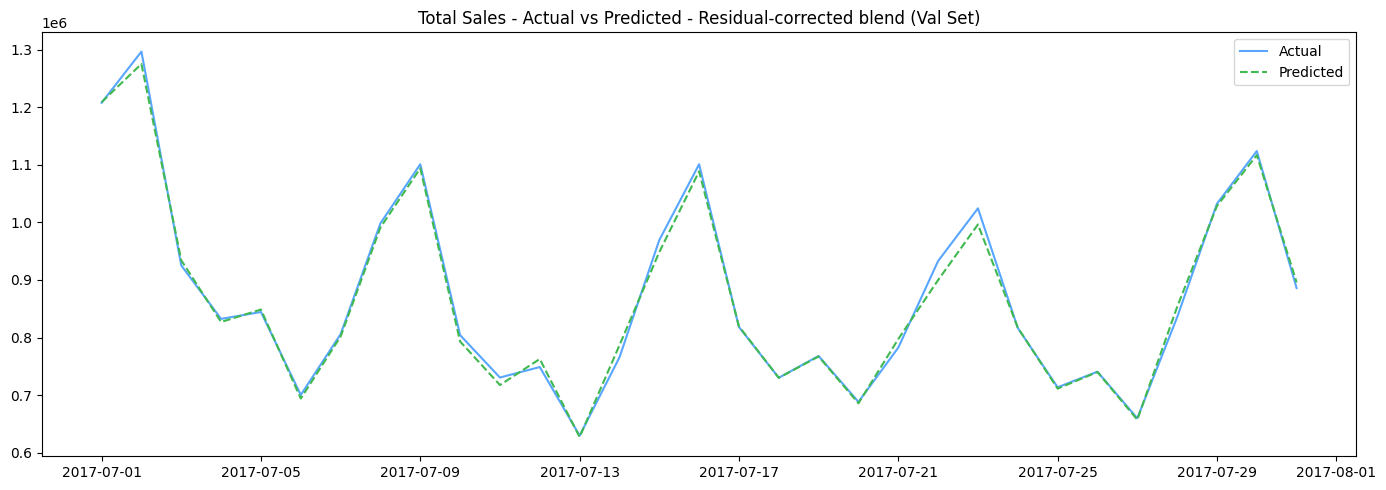

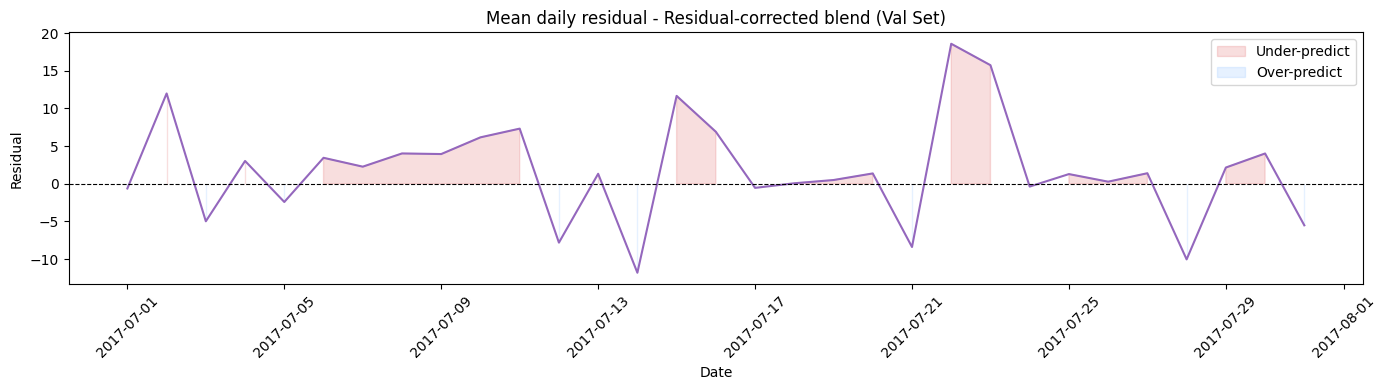

In [6]:
date_val = pd.to_datetime(X_val_raw[["year", "month", "day"]])

blend_val_df = pd.DataFrame(
    {
        "date": date_val.values,
        "actual": y_val_orig["sales"].values,
        "predicted": np.maximum(np.expm1(corrected_val_blend), 0),
    }
)
blend_val_df["residual"] = blend_val_df["actual"] - blend_val_df["predicted"]

daily_val = blend_val_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_val.index, daily_val["actual"], label="Actual", color="#58a6ff")
plt.plot(daily_val.index, daily_val["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total Sales - Actual vs Predicted - Residual-corrected blend (Val Set)")
plt.legend()
plt.tight_layout()
plt.show()

daily_resid_val = blend_val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_val.index, daily_resid_val.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(
    daily_resid_val.index,
    daily_resid_val.values,
    0,
    where=daily_resid_val.values > 0,
    alpha=0.15,
    color="#d62728",
    label="Under-predict",
)
ax.fill_between(
    daily_resid_val.index,
    daily_resid_val.values,
    0,
    where=daily_resid_val.values < 0,
    alpha=0.15,
    color="#58a6ff",
    label="Over-predict",
)
ax.set_title("Mean daily residual - Residual-corrected blend (Val Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


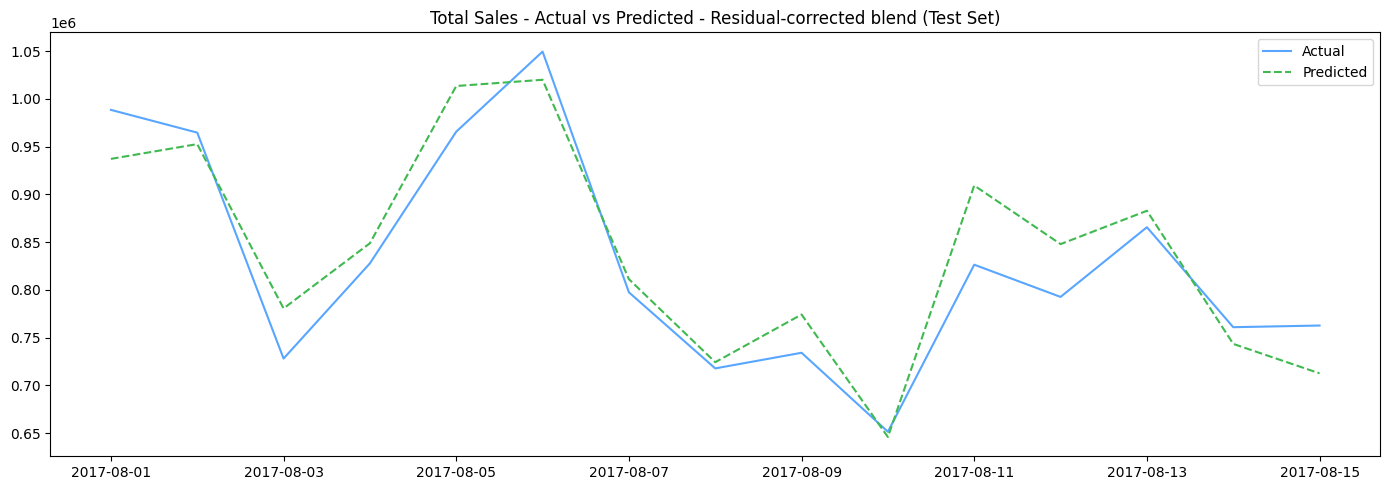

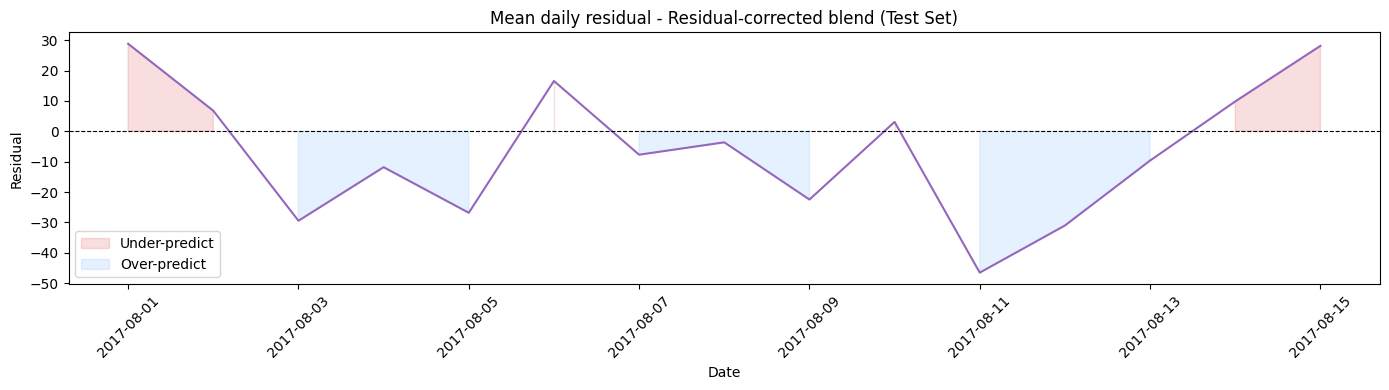

In [7]:
date_test = pd.to_datetime(X_test_raw[["year", "month", "day"]])

blend_test_df = pd.DataFrame(
    {
        "date": date_test.values,
        "actual": y_test_orig["sales"].values,
        "predicted": np.maximum(np.expm1(corrected_test_blend), 0),
    }
)
blend_test_df["residual"] = blend_test_df["actual"] - blend_test_df["predicted"]

daily_test = blend_test_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_test.index, daily_test["actual"], label="Actual", color="#58a6ff")
plt.plot(daily_test.index, daily_test["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total Sales - Actual vs Predicted - Residual-corrected blend (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

daily_resid_test = blend_test_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_test.index, daily_resid_test.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(
    daily_resid_test.index,
    daily_resid_test.values,
    0,
    where=daily_resid_test.values > 0,
    alpha=0.15,
    color="#d62728",
    label="Under-predict",
)
ax.fill_between(
    daily_resid_test.index,
    daily_resid_test.values,
    0,
    where=daily_resid_test.values < 0,
    alpha=0.15,
    color="#58a6ff",
    label="Over-predict",
)
ax.set_title("Mean daily residual - Residual-corrected blend (Test Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


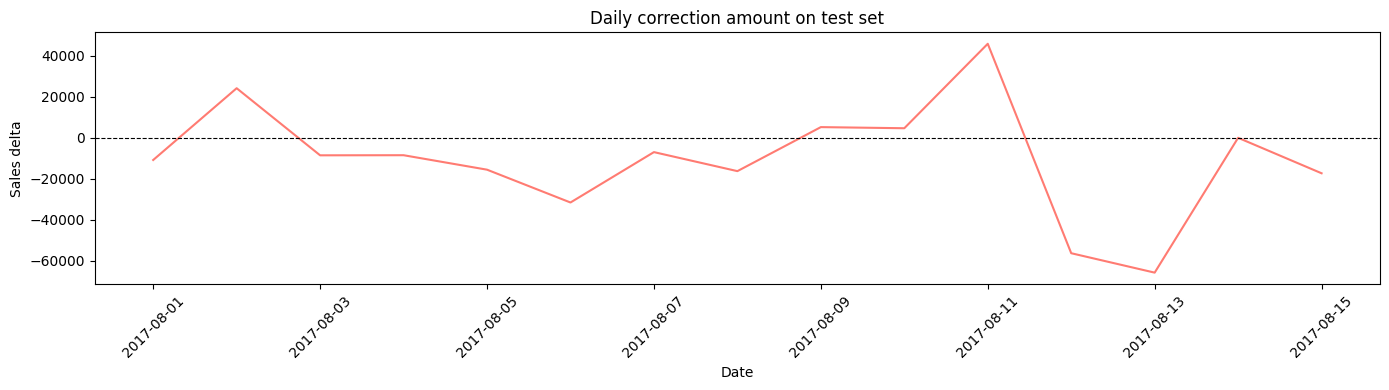

Largest daily correction magnitudes
date
2017-08-13   65828.92
2017-08-12   56356.66
2017-08-11   45781.69
2017-08-06   31626.81
2017-08-02   24105.03
2017-08-15   17374.73
2017-08-08   16330.02
2017-08-05   15617.89
2017-08-01   10897.71
2017-08-03    8615.56


In [8]:
correction_df = pd.DataFrame(
    {
        "date": pd.to_datetime(X_test_raw[["year", "month", "day"]]).values,
        "base_prediction": np.maximum(np.expm1(best_global_test_blend), 0),
        "corrected_prediction": np.maximum(np.expm1(corrected_test_blend), 0),
        "actual": y_test_orig["sales"].values,
    }
)
correction_df["correction_amount"] = correction_df["corrected_prediction"] - correction_df["base_prediction"]

daily_correction = correction_df.groupby("date")[["actual", "base_prediction", "corrected_prediction", "correction_amount"]].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_correction.index, daily_correction["correction_amount"], color="#ff7b72", linewidth=1.5)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily correction amount on test set")
plt.xlabel("Date")
plt.ylabel("Sales delta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Largest daily correction magnitudes")
print(
    daily_correction["correction_amount"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .rename("abs_daily_correction")
    .to_string(float_format="{:.2f}".format)
)


In [9]:
top_under_dates = (
    blend_test_df.groupby("date")["residual"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .rename("mean_residual")
)
print("Top under-predicted dates")
print(top_under_dates.to_string(float_format="{:.2f}".format))


Top under-predicted dates
date
2017-08-01    28.80
2017-08-15    28.11
2017-08-06    16.55
2017-08-14     9.81
2017-08-02     6.76
2017-08-10     3.07
2017-08-08    -3.64
2017-08-07    -7.72
2017-08-13    -9.66
2017-08-04   -11.83


In [10]:
top_over_dates = (
    blend_test_df.groupby("date")["residual"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .rename("mean_residual")
)
print("Top over-predicted dates")
print(top_over_dates.to_string(float_format="{:.2f}".format))


Top over-predicted dates
date
2017-08-11   -46.54
2017-08-12   -31.03
2017-08-03   -29.46
2017-08-05   -26.84
2017-08-09   -22.48
2017-08-04   -11.83
2017-08-13    -9.66
2017-08-07    -7.72
2017-08-08    -3.64
2017-08-10     3.07
